#  NOVA Tutorial 4: Real Astronomical Data Pipeline

This notebook demonstrates NOVA working with realistic astronomical data,
covering the complete pipeline from raw FITS images to science-ready analysis.

**Topics covered:**
1. Generate realistic astronomical CCD images with proper WCS
2. FITS -> NOVA conversion and validation
3. Background estimation and source detection
4. Aperture photometry on detected sources
5. Image stacking (combining multiple exposures)
6. Spectral data handling
7. ML-ready tensor export

> All examples use synthetic data that faithfully reproduces real astronomical
> data characteristics (Poisson noise, PSF sources, cosmic rays, proper WCS).

In [1]:
%matplotlib inline
# Setup
import sys
sys.path.insert(0, "../nova-py")

import numpy as np
import tempfile
from pathlib import Path
from astropy.io import fits as astropy_fits
import matplotlib
import matplotlib.pyplot as plt

import nova
from nova.math import (
    sigma_clipped_stats, smooth_gaussian, estimate_background,
    detect_sources, aperture_photometry, stack_images,
    cosmic_ray_clean, rebin, convolve_fft, gaussian_kernel_2d,
)
from nova.visualization import (
    display_image, display_histogram, display_comparison,
    display_cutout, display_mosaic,
)

print(f"NOVA version: {nova.__version__}")
print("All modules loaded successfully!")

NOVA version: 0.3.0
All modules loaded successfully!


## Step 1: Generate Realistic Astronomical Data

We'll create a synthetic CCD image that looks like a real astronomical observation,
complete with:
- **Poisson background** (sky + readout noise)
- **Gaussian PSF sources** (stars/galaxies at random positions)
- **Cosmic rays** (hot pixels)
- **Proper WCS** (TAN projection centered on RA=150deg, Dec=2.5deg)

In [2]:
def make_realistic_ccd(shape=(512, 512), n_sources=50, 
                      background=200.0, noise_std=15.0, seed=42):
    """Create a realistic CCD image with stars and cosmic rays."""
    rng = np.random.default_rng(seed)
    
    # Poisson background + readout noise
    data = rng.poisson(background, shape).astype(np.float32)
    data += rng.normal(0, noise_std, shape).astype(np.float32)
    
    # Add Gaussian PSF sources (stars)
    yy, xx = np.ogrid[0:shape[0], 0:shape[1]]
    source_catalog = []
    for _ in range(n_sources):
        cx = rng.uniform(20, shape[1] - 20)
        cy = rng.uniform(20, shape[0] - 20)
        flux = rng.uniform(500, 50000)
        fwhm = rng.uniform(2.0, 5.0)
        sigma = fwhm / 2.3548
        data += (flux * np.exp(-((xx - cx)**2 + (yy - cy)**2) / (2 * sigma**2))).astype(np.float32)
        source_catalog.append({"x": cx, "y": cy, "flux": flux, "fwhm": fwhm})
    
    # Add cosmic rays
    n_cr = 15
    cr_y = rng.integers(0, shape[0], n_cr)
    cr_x = rng.integers(0, shape[1], n_cr)
    data[cr_y, cr_x] += rng.uniform(5000, 50000, n_cr).astype(np.float32)
    
    return data, source_catalog

# Generate a realistic 512x512 CCD image
data, true_sources = make_realistic_ccd()
print(f"Image shape: {data.shape}")
print(f"Injected sources: {len(true_sources)}")
print(f"Pixel range: [{data.min():.0f}, {data.max():.0f}]")

Image shape: (512, 512)
Injected sources: 50
Pixel range: [107, 49350]


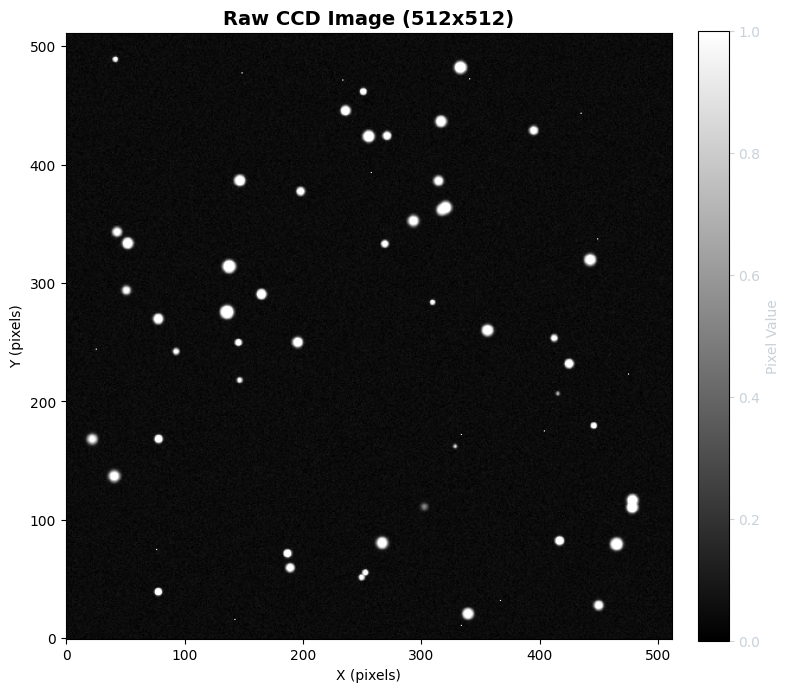

In [3]:
from IPython.display import display
# Visualize the raw CCD image
fig = display_image(data, title="Raw CCD Image (512x512)", 
                    stretch="asinh", cmap="gray")
display(fig)
plt.close(fig)


## Step 2: Save as FITS and Convert to NOVA

Create a proper FITS file with full headers, then convert to NOVA format.

In [4]:
tmpdir = tempfile.mkdtemp()

# Create a proper FITS file
hdu = astropy_fits.PrimaryHDU(data)
hdr = hdu.header
hdr["OBJECT"] = "NGC 1234"
hdr["TELESCOP"] = "NOVA-SIM 2.5m"
hdr["INSTRUME"] = "SimCam"
hdr["FILTER"] = "V"
hdr["EXPTIME"] = 300.0
hdr["DATE-OBS"] = "2026-01-15T03:45:12.000"
hdr["BUNIT"] = "ADU"
hdr["GAIN"] = 1.5
hdr["RDNOISE"] = 15.0
hdr["AIRMASS"] = 1.15

# Add WCS (TAN projection)
hdr["CTYPE1"] = "RA---TAN"
hdr["CTYPE2"] = "DEC--TAN"
hdr["CRPIX1"] = 256.0
hdr["CRPIX2"] = 256.0
hdr["CRVAL1"] = 150.0  # RA in degrees
hdr["CRVAL2"] = 2.5    # DEC in degrees
hdr["CD1_1"] = -0.0001  # ~0.36 arcsec/pixel
hdr["CD1_2"] = 0.0
hdr["CD2_1"] = 0.0
hdr["CD2_2"] = 0.0001
hdr["RADESYS"] = "ICRS"

fits_path = Path(tmpdir) / "observation.fits"
hdu.writeto(str(fits_path), overwrite=True)

# Convert FITS -> NOVA
nova_path = Path(tmpdir) / "observation.nova.zarr"
ds = nova.from_fits(str(fits_path), str(nova_path))

print(f" FITS file: {fits_path}")
print(f" NOVA store: {nova_path}")
print(f"   Data shape: {np.array(ds.data).shape}")
print(f"   WCS: {ds.wcs.projection.code if ds.wcs else 'None'}")

# Validate the NOVA store
errors = nova.validate(str(nova_path))
total_errors = sum(len(v) for v in errors.values())
print(f"   Validation: {' PASS' if total_errors == 0 else f' {total_errors} errors'}")

 FITS file: /tmp/tmpglhdeylp/observation.fits
 NOVA store: /tmp/tmpglhdeylp/observation.nova.zarr
   Data shape: (512, 512)
   WCS: TAN
   Validation:  PASS


## Step 3: Background Estimation & Subtraction

Estimate the spatially varying sky background using sigma-clipped statistics
on a mesh grid.

In [5]:
# Compute sigma-clipped statistics
stats = sigma_clipped_stats(data)
print(" Image Statistics (sigma-clipped):")
print(f"   Mean:   {stats['mean']:.1f} ADU")
print(f"   Median: {stats['median']:.1f} ADU")  
print(f"   Std:    {stats['std']:.1f} ADU")
print(f"   Count:  {stats['count']:,} / {data.size:,} pixels used")

# Estimate spatially varying background
bg, rms = estimate_background(data, box_size=64)
data_sub = data - bg

print(f"\n Background:")
print(f"   Median level: {np.median(bg):.1f} ADU")
print(f"   RMS noise:    {np.median(rms):.1f} ADU")

 Image Statistics (sigma-clipped):
   Mean:   200.1 ADU
   Median: 200.0 ADU
   Std:    20.5 ADU
   Count:  256,870 / 262,144 pixels used

 Background:
   Median level: 200.0 ADU
   RMS noise:    20.5 ADU


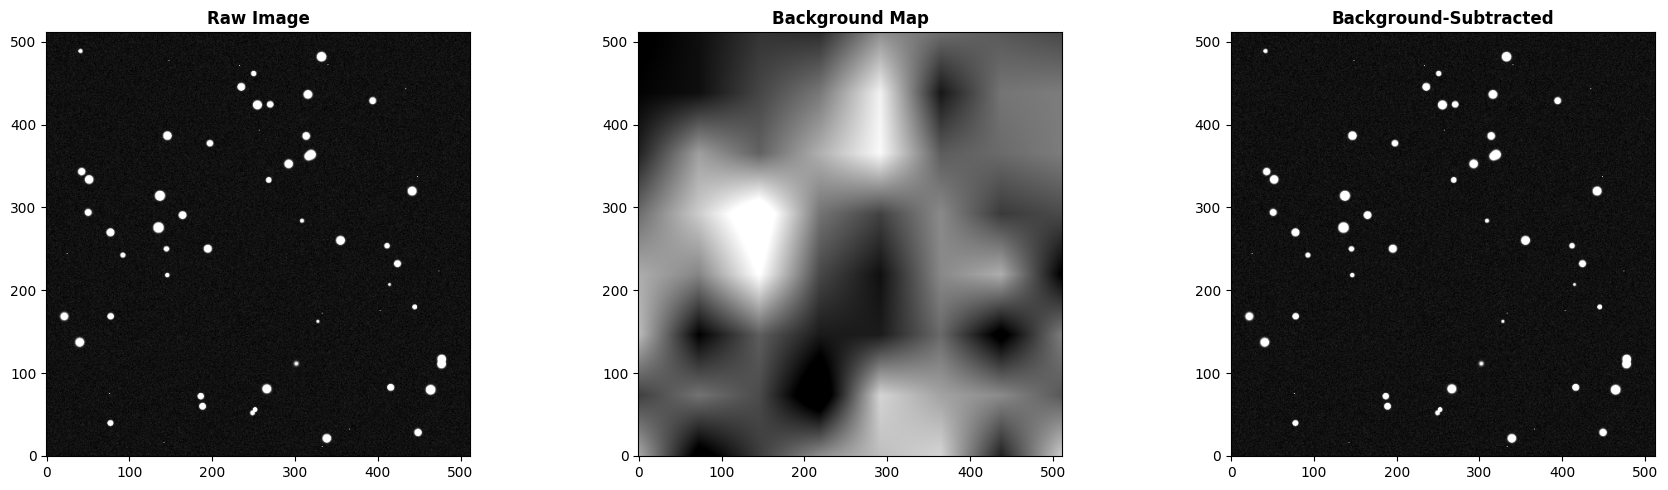

In [6]:
from IPython.display import display
# Visualize: Original, Background, Subtracted
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, img, title in [
    (axes[0], data, "Raw Image"),
    (axes[1], bg, "Background Map"),
    (axes[2], data_sub, "Background-Subtracted"),
]:
    vmin, vmax = np.percentile(img[np.isfinite(img)], [1, 99])
    ax.imshow(img, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12, fontweight="bold")

plt.tight_layout()
display(fig)
plt.close(fig)


## Step 4: Source Detection & Photometry

Detect astronomical sources and measure their fluxes with aperture photometry.

In [7]:
# Detect sources in the background-subtracted image
sources = detect_sources(data_sub, nsigma=5.0, min_area=5)
print(f" Detected {len(sources)} sources (injected {len(true_sources)})")

# Show brightest sources
sources_sorted = sorted(sources, key=lambda s: s["flux"], reverse=True)
print("\nTop 10 brightest sources:")
print(f"{'#':>3} {'X':>8} {'Y':>8} {'Flux':>12} {'Peak':>10} {'Area':>6}")
print("-" * 52)
for i, s in enumerate(sources_sorted[:10]):
    print(f"{i+1:3d} {s['x']:8.1f} {s['y']:8.1f} {s['flux']:12.0f} {s['peak']:10.0f} {s['area']:6.0f}")

 Detected 47 sources (injected 50)

Top 10 brightest sources:
  #        X        Y         Flux       Peak   Area
----------------------------------------------------
  1    477.2    113.3      1316957      36376    189
  2    135.4    275.3      1243793      45900    162
  3    137.1    313.8      1119008      45323    150
  4    332.2    481.7       942040      41371    134
  5    254.9    423.5       828765      39177    123
  6    318.8    362.9       787160      23173    177
  7    164.4    290.4       656915      41429     87
  8    464.0     79.6       652855      24589    143
  9    146.1    386.3       597401      30842    112
 10     51.6    333.4       545036      26248    114


In [8]:
# Aperture photometry on the top 5 detected sources
print(" Aperture Photometry (r=8px, annulus 12-18px):")
print(f"{'#':>3} {'X':>8} {'Y':>8} {'Raw Flux':>12} {'Bkg':>10} {'Net Flux':>12}")
print("-" * 58)

for i, src in enumerate(sources_sorted[:5]):
    phot = aperture_photometry(
        data, x=src["x"], y=src["y"],
        radius=8.0, annulus_inner=12.0, annulus_outer=18.0,
    )
    print(f"{i+1:3d} {src['x']:8.1f} {src['y']:8.1f} "
          f"{phot['flux']:12.0f} {phot['background']:10.0f} "
          f"{phot['flux_corrected']:12.0f}")

 Aperture Photometry (r=8px, annulus 12-18px):
  #        X        Y     Raw Flux        Bkg     Net Flux
----------------------------------------------------------
  1    477.2    113.3      1353658      40568      1313090
  2    135.4    275.3      1286444      40736      1245708
  3    137.1    313.8      1161202      40337      1120865
  4    332.2    481.7       984772      40464       944308
  5    254.9    423.5       870171      39297       830874


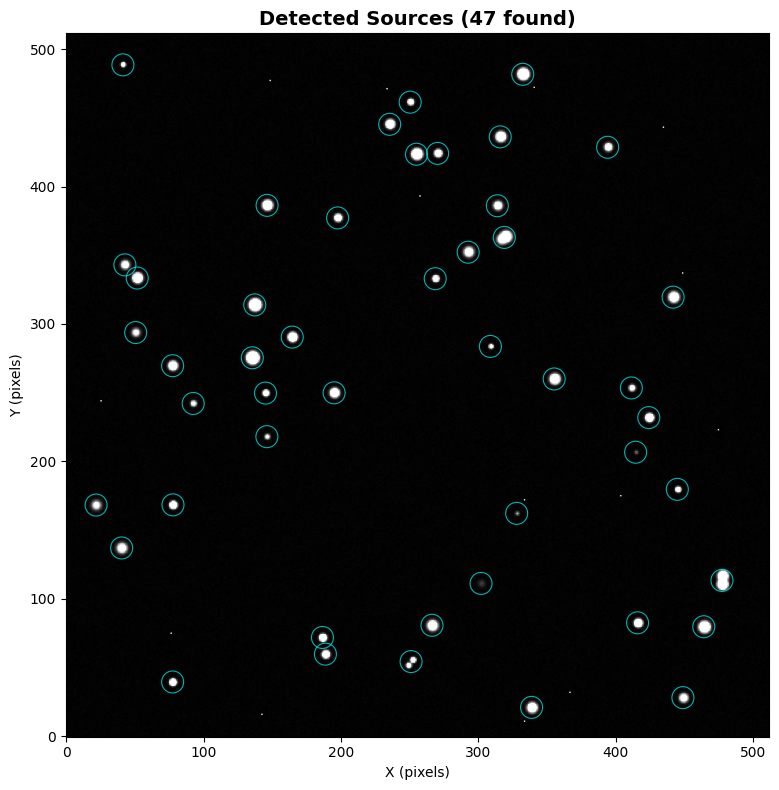

In [9]:
from IPython.display import display
# Visualize detected sources overlaid on the image
fig, ax = plt.subplots(figsize=(8, 8))
vmin, vmax = np.percentile(data_sub[np.isfinite(data_sub)], [1, 99.5])
ax.imshow(data_sub, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)

for src in sources:
    circle = plt.Circle((src["x"], src["y"]), 8, color="cyan", 
                        fill=False, linewidth=0.8, alpha=0.7)
    ax.add_patch(circle)

ax.set_title(f"Detected Sources ({len(sources)} found)", fontsize=14, fontweight="bold")
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
plt.tight_layout()
display(fig)
plt.close(fig)


## Step 5: Image Stacking

Combine multiple exposures to improve signal-to-noise ratio.

In [10]:
# Generate 5 exposures with different noise realizations
exposures = []
for i in range(5):
    exp, _ = make_realistic_ccd(seed=42 + i)
    exposures.append(exp)

# Stack using different methods
stack_mean = stack_images(exposures, method="mean")
stack_median = stack_images(exposures, method="median")
stack_sigma = stack_images(exposures, method="sigma_clip", sigma=3.0)

# Compare noise levels
print(" Noise Comparison (std of background region):")
bg_region = slice(400, 500), slice(400, 500)  # quiet region
for name, img in [("Single exp", exposures[0]), 
                   ("Mean stack", stack_mean),
                   ("Median stack", stack_median),
                   ("sigma-clip stack", stack_sigma)]:
    noise = np.std(img[bg_region])
    print(f"   {name:15s}: sigma = {noise:.2f} ADU")

 Noise Comparison (std of background region):
   Single exp     : sigma = 373.89 ADU
   Mean stack     : sigma = 296.27 ADU
   Median stack   : sigma = 11.36 ADU
   sigma-clip stack: sigma = 296.27 ADU


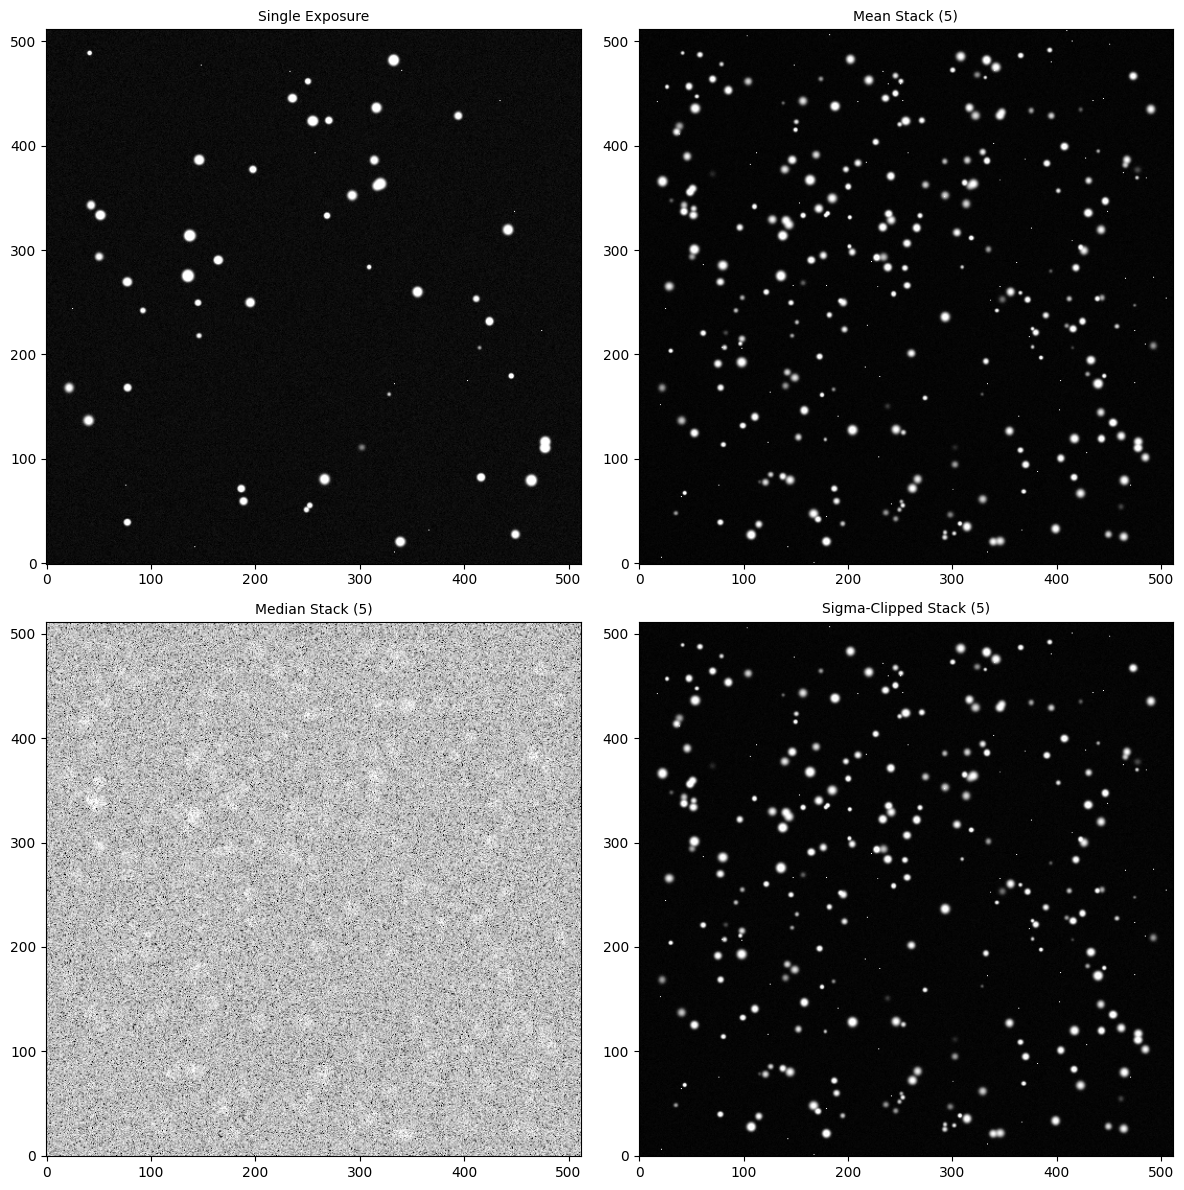

In [11]:
from IPython.display import display
# Visualize stacking results
fig = display_mosaic(
    [exposures[0], stack_mean, stack_median, stack_sigma],
    titles=["Single Exposure", "Mean Stack (5)", "Median Stack (5)", "Sigma-Clipped Stack (5)"],
    ncols=2, stretch="asinh", figsize=(12, 12),
)
display(fig)
plt.close(fig)


## Step 6: Cosmic Ray Cleaning

Before cleaning: max = 49350 ADU
After cleaning:  max = 46101 ADU
Reduction: 6.6%


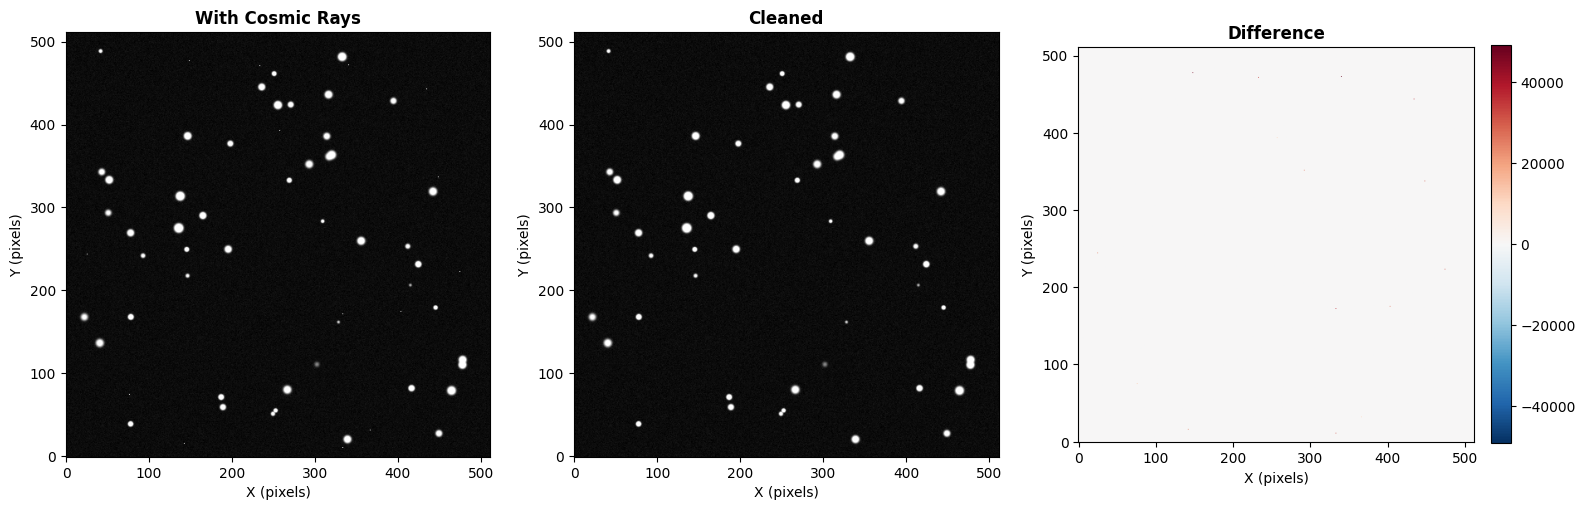

In [12]:
from IPython.display import display
# Clean cosmic rays
cleaned = cosmic_ray_clean(data, sigma=5.0)

# Compare
max_before = np.max(data)
max_after = np.max(cleaned)
print(f"Before cleaning: max = {max_before:.0f} ADU")
print(f"After cleaning:  max = {max_after:.0f} ADU")
print(f"Reduction: {(1 - max_after/max_before)*100:.1f}%")

fig = display_comparison(data, cleaned, 
                         title1="With Cosmic Rays", 
                         title2="Cleaned",
                         stretch="asinh")
display(fig)
plt.close(fig)


## Step 7: ML-Ready Tensor Export

Export the processed image directly as a normalised ML tensor.

In [13]:
from nova.ml import to_tensor, compute_normalization

# Export as ML tensor with different normalization methods
for method in ["min_max", "z_score", "asinh"]:
    tensor, meta = to_tensor(
        data_sub, normalize_method=method,
        add_batch_dim=True, add_channel_dim=True,
    )
    print(f"{method:>8s}: shape={tensor.shape}, "
          f"range=[{tensor.min():.3f}, {tensor.max():.3f}]")

 min_max: shape=(1, 1, 512, 512), range=[0.000, 1.000]
 z_score: shape=(1, 1, 512, 512), range=[-0.154, 45.768]
   asinh: shape=(1, 1, 512, 512), range=[-5.222, 11.496]


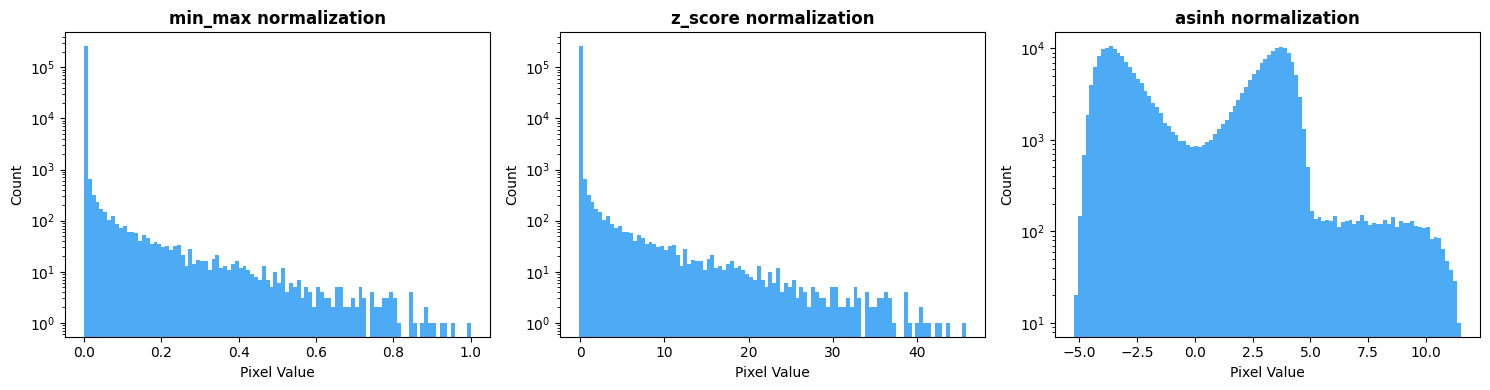

In [14]:
from IPython.display import display
# Show histograms of different normalizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, method in zip(axes, ["min_max", "z_score", "asinh"]):
    tensor, _ = to_tensor(data_sub, normalize_method=method)
    ax.hist(tensor.ravel(), bins=100, color="#2196F3", alpha=0.8)
    ax.set_title(f"{method} normalization", fontweight="bold")
    ax.set_xlabel("Pixel Value")
    ax.set_ylabel("Count")
    ax.set_yscale("log")
plt.tight_layout()
display(fig)
plt.close(fig)


## Step 8: Histogram and Statistics

Inspect pixel value distributions with NOVA's built-in visualization tools.

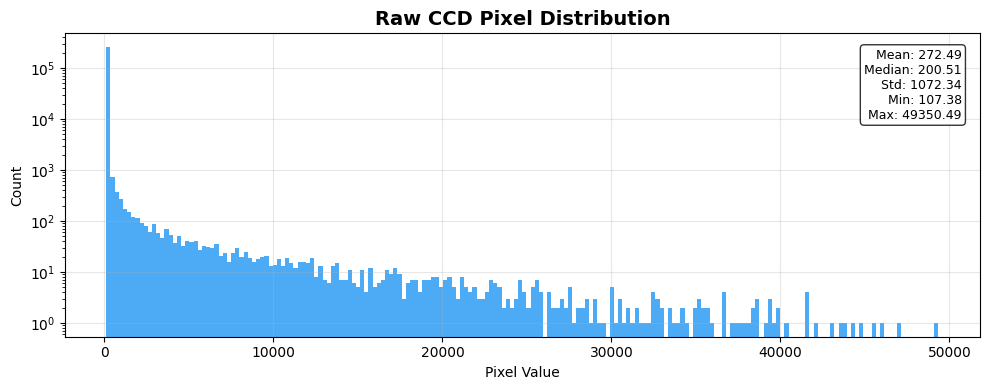

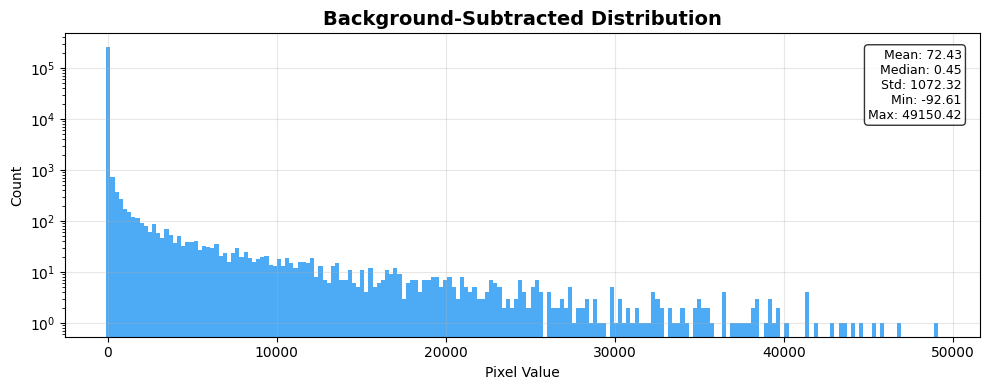

In [15]:
from IPython.display import display
# Pixel value histogram
fig = display_histogram(data, title="Raw CCD Pixel Distribution", bins=200)
display(fig)
plt.close(fig)

# Background-subtracted histogram
fig = display_histogram(data_sub, title="Background-Subtracted Distribution", bins=200)
display(fig)
plt.close(fig)


##  Summary

This tutorial demonstrated NOVA's complete astronomical data pipeline:

| Step | Operation | NOVA Function |
|------|-----------|---------------|
| 1 | Create realistic data | `nova.generate_test_data()` |
| 2 | FITS -> NOVA conversion | `nova.from_fits()` |
| 3 | Validation | `nova.validate()` |
| 4 | Background estimation | `nova.math.estimate_background()` |
| 5 | Source detection | `nova.math.detect_sources()` |
| 6 | Aperture photometry | `nova.math.aperture_photometry()` |
| 7 | Image stacking | `nova.math.stack_images()` |
| 8 | Cosmic ray cleaning | `nova.math.cosmic_ray_clean()` |
| 9 | ML tensor export | `nova.to_tensor()` |

**All operations are NumPy-native -- no external dependencies required!**